# CRÉATION D'UN RÉSEAU NEURONAL POUR LA PRÉDICTION DES PRIX DES VOITURES

Prétraitement des Données pour la Prédiction du Prix des Véhicules

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Load the dataset
file_path = '../../cleaned_data/cars_data_cleaned.csv'
data = pd.read_csv(file_path)

# Identify features and target
target = 'prix'  # Assuming 'prix' is the target variable
X = data.drop(columns=[target])
y = data[target]

# Identify numerical and categorical columns
numerical_columns = X.select_dtypes(include=['int64', 'float64']).columns
categorical_columns = X.select_dtypes(include=['object']).columns

# Preprocessing for numerical data: Imputation and Scaling
numerical_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

# Preprocessing for categorical data: Imputation and One-Hot Encoding
categorical_transformer = Pipeline(steps=[
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# Combine preprocessors in a column transformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_columns),
        ('cat', categorical_transformer, categorical_columns)
    ]
)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Apply transformations to training and testing data
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

# Output the shapes of the processed datasets
print("Shape of X_train:", X_train_transformed.shape)
print("Shape of X_test:", X_test_transformed.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)


Shape of X_train: (17809, 376)
Shape of X_test: (4453, 376)
Shape of y_train: (17809,)
Shape of y_test: (4453,)


Entraînement d'un Modèle de Régression pour la Prédiction du Prix des Véhicules avec TensorFlow

In [17]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# Define the model
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_transformed.shape[1],)),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(1)  # Single neuron for regression task
])

# Compile the model
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Train the model
history = model.fit(
    X_train_transformed, y_train,
    validation_data=(X_test_transformed, y_test),
    epochs=50,
    batch_size=32,
    verbose=1
)

# Evaluate the model
loss, mae = model.evaluate(X_test_transformed, y_test, verbose=0)
print(f"Test Loss: {loss:.4f}, Test MAE: {mae:.4f}")


C:\Users\HP\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
557/557 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 11586381824.0000 - mae: 101728.3281 - val_loss: 6328597504.0000 - val_mae: 72337.7500
Epoch 2/50
557/557 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - loss: 3863802624.0000 - mae: 51378.3984 - val_loss: 805577664.0000 - val_mae: 21500.1270
Epoch 3/50
557/557 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - loss: 799249792.0000 - mae: 21841.3027 - val_loss: 577357504.0000 - val_mae: 18580.8516
Epoch 4/50
557/557 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 636318336.0000 - mae: 19374.6992 - val_loss: 464175360.0000 - val_mae: 16425.6641
Epoch 5/50
557/557 ━━━━━━━━━━━━━━━━━━━━ 16s 26ms/step - loss: 538505536.0000 - mae: 17726.0332 - val_loss: 397482016.0000 - val_mae: 15144.5391
Epoch 6/50
557/557 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - loss: 492072384.0000 - mae: 16825.2930 - val_loss: 356800224.0000 - val_mae: 14295.5566
Epoch 7/50
557/557 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - loss: 456685664.0000 - mae: 16155.9502 - val_loss: 331642176.0000 - val_mae: 13644

Évaluation des Performances du Modèle de Régression à l'aide des Métriques MSE, MAE et R²

In [19]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Faire des prédictions sur l'ensemble de test
y_test_pred = model.predict(X_test_transformed).flatten()

# Calculer les métriques
mse = mean_squared_error(y_test, y_test_pred)
mae = mean_absolute_error(y_test, y_test_pred)
r2 = r2_score(y_test, y_test_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Coefficient of Determination (R^2): {r2:.4f}")


140/140 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step
Mean Squared Error (MSE): 168946264.75
Mean Absolute Error (MAE): 9384.23
Coefficient of Determination (R^2): 0.8665


Test du Modèle sur des Échantillons de Test et Comparaison des Prédictions avec les Valeurs Réelles

In [21]:
# Example: Test the model on a few samples from the test set
sample_indices = [0, 1, 2]  # Replace with desired indices or use random sampling
X_sample = X_test.iloc[sample_indices]
y_sample_actual = y_test.iloc[sample_indices]

# Preprocess the sample data
X_sample_transformed = preprocessor.transform(X_sample)

# Make predictions
y_sample_pred = model.predict(X_sample_transformed)

# Compare predictions with actual values
for i, (pred, actual) in enumerate(zip(y_sample_pred.flatten(), y_sample_actual)):
    print(f"Sample {i+1}: Predicted Price = {pred:.2f}, Actual Price = {actual:.2f}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 461ms/step
Sample 1: Predicted Price = 130557.12, Actual Price = 105000.00
Sample 2: Predicted Price = 174706.53, Actual Price = 200000.00
Sample 3: Predicted Price = 125843.57, Actual Price = 125000.00


Prédiction du Prix pour de Nouvelles Données à l'Aide du Modèle Entraîné

In [53]:
# Example new data
new_data = pd.DataFrame({
        "marque": ["toyota"],
        "modele": ["corolla"],
        "annee-modele": [2018],
        "kilometrage": [85000],
        "type_de_carburant": ["diesel"],
        "puissance_fiscale": [7],
        "boite_de_vitesses": ["automatique"],
        "nombre_de_portes": [4],
        "origine":[ "importé neuve"],
        "premiere_main": [1],
        "etat": ["excellent"],
        "airbags": [6],
        "climatisation": [1],
        "abs": [1],
        "esp": [1],
        "cd/mp3/bluetooth": [1]
    })

# Preprocess new data
new_data_transformed = preprocessor.transform(new_data)

# Predict
new_predictions = model.predict(new_data_transformed)
print(f"Predicted Price for New Data: {new_predictions[0][0]:.2f}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step
Predicted Price for New Data: 163717.16


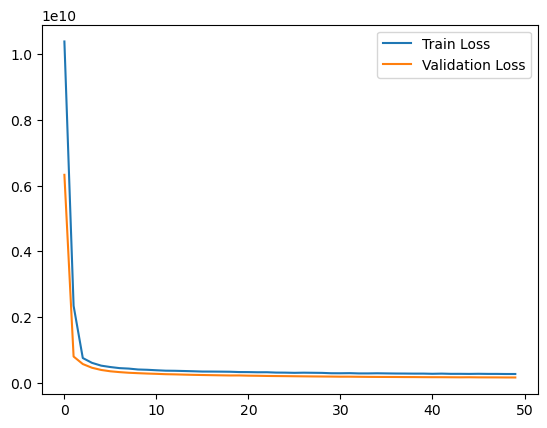

In [25]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.show()


In [45]:
import joblib

# Save the model as a .h5 file
model.save('../../backend/car_price_model.h5')

# Save the preprocessor as a .pkl file
joblib.dump(preprocessor, '../../backend/cars_preprocessor.pkl')

['../../backend/cars_preprocessor.pkl']

In [49]:
import pandas as pd
import joblib
from tensorflow.keras.models import load_model
from tensorflow.keras.metrics import MeanSquaredError

# Load the saved model
custom_objects = {"mse": MeanSquaredError()}  # Replace 'mse' with the proper function
model = load_model('car_price_model.h5', custom_objects=custom_objects)

# Example new data (replace this with actual data you want to predict on)
new_data = pd.DataFrame({
        "marque": ["toyota"],
        "modele": ["corolla"],
        "annee-modele": [2018],
        "kilometrage": [85000],
        "type_de_carburant": ["diesel"],
        "puissance_fiscale": [7],
        "boite_de_vitesses": ["automatique"],
        "nombre_de_portes": [4],
        "origine":[ "importé neuf"],
        "premiere_main": [1],
        "etat": ["excellent"],
        "airbags": [6],
        "climatisation": [1],
        "abs": [1],
        "esp": [1],
        "cd/mp3/bluetooth": [1]
    })

# Load the preprocessor
preprocessor = joblib.load('preprocessor.pkl')

# Preprocess the new data using the same transformations as the training data
new_data_transformed = preprocessor.transform(new_data)

# Make predictions for the new data
new_predictions = model.predict(new_data_transformed)

# Output the predicted price
predicted_price = new_predictions[0][0]  # Since it's a single prediction
print(f"Predicted Price for New Car: {predicted_price:.2f}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step
Predicted Price for New Car: 146277.64
